In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/thnhtrungnguynmif/vietnamhistory-nli/data_tk1_NLI_VietnamHistory.csv")
print(df.head())

                                            premise   \
0  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
1  Việt Nam Tuyên truyền Giải phóng quân là một t...   
2  ngày 12 tháng 3 năm 1945, Ban Thường vụ Trung ...   
3  Dưới sự cai trị của Nhật, từ tháng 10 năm 1944...   
4  Cách mạng Tháng Tám, còn gọi là Tổng khởi nghĩ...   

                                       contradiction  \
0  Việt Nam Tuyên truyền Giải phóng quân được thà...   
1  Việt Nam Tuyên truyền Giải phóng quân không có...   
2  Chỉ thị được ban hành để kêu gọi hợp tác với q...   
3  Nạn đói năm 1945 không gây thiệt hại lớn về nh...   
4  Cách mạng Tháng Tám diễn ra hòa bình và không ...   

                                          entailment  \
0  Việt Nam Tuyên truyền Giải phóng quân được thà...   
1  Việt Nam Tuyên truyền Giải phóng quân là lực l...   
2  Tháng 3 năm 1945, Đảng Cộng sản Việt Nam đã kê...   
3  Trong thời gian Nhật chiếm đóng, Việt Nam xảy ...   
4  Cách mạng Tháng Tám năm 1945 đã lật đổ chín

In [2]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)


Index(['premise', 'contradiction', 'entailment', 'neutral'], dtype='object')


In [3]:
rows = []

for _, row in df.iterrows():

    premise = row["premise"]

    rows.append({
        "premise": premise,
        "hypothesis": row["contradiction"],
        "label": "contradiction"
    })

    rows.append({
        "premise": premise,
        "hypothesis": row["entailment"],
        "label": "entailment"
    })

    rows.append({
        "premise": premise,
        "hypothesis": row["neutral"],
        "label": "neutral"
    })

nli_df = pd.DataFrame(rows)

print(nli_df.head())

                                             premise  \
0  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
1  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
2  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
3  Việt Nam Tuyên truyền Giải phóng quân là một t...   
4  Việt Nam Tuyên truyền Giải phóng quân là một t...   

                                          hypothesis          label  
0  Việt Nam Tuyên truyền Giải phóng quân được thà...  contradiction  
1  Việt Nam Tuyên truyền Giải phóng quân được thà...     entailment  
2  Cuối năm 1944, phong trào vũ trang cách mạng ở...        neutral  
3  Việt Nam Tuyên truyền Giải phóng quân không có...  contradiction  
4  Việt Nam Tuyên truyền Giải phóng quân là lực l...     entailment  


In [4]:
label_map = {
    "contradiction": 0,
    "neutral": 1,
    "entailment": 2
}

nli_df["label"] = nli_df["label"].map(label_map)

In [5]:
print(nli_df.head())

                                             premise  \
0  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
1  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
2  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
3  Việt Nam Tuyên truyền Giải phóng quân là một t...   
4  Việt Nam Tuyên truyền Giải phóng quân là một t...   

                                          hypothesis  label  
0  Việt Nam Tuyên truyền Giải phóng quân được thà...      0  
1  Việt Nam Tuyên truyền Giải phóng quân được thà...      2  
2  Cuối năm 1944, phong trào vũ trang cách mạng ở...      1  
3  Việt Nam Tuyên truyền Giải phóng quân không có...      0  
4  Việt Nam Tuyên truyền Giải phóng quân là lực l...      2  


In [6]:
sentences = nli_df["premise"].tolist() + nli_df["hypothesis"].tolist()

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

sentences = [clean_text(s) for s in sentences]

# Tách từ

## underthesea

In [8]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 71.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.5 MB/s eta 0:00:00


In [9]:
# underthesea
from underthesea import word_tokenize

tokenized_underthesea = [word_tokenize(s) for s in sentences]

In [10]:

for s in sentences[:10]:   
    tokens = word_tokenize(s)
    
    print("Câu gốc:", s)
    print("Tokenized:", tokens)


Câu gốc: ngày 22 tháng 12 năm 1944 võ nguyên giáp thành lập một trung đội 34 người mang tên việt nam tuyên truyền giải phóng quân
Tokenized: ['ngày', '22', 'tháng', '12', 'năm', '1944', 'võ nguyên', 'giáp', 'thành lập', 'một', 'trung đội', '34', 'người', 'mang', 'tên', 'việt nam', 'tuyên truyền', 'giải phóng', 'quân']
Câu gốc: ngày 22 tháng 12 năm 1944 võ nguyên giáp thành lập một trung đội 34 người mang tên việt nam tuyên truyền giải phóng quân
Tokenized: ['ngày', '22', 'tháng', '12', 'năm', '1944', 'võ nguyên', 'giáp', 'thành lập', 'một', 'trung đội', '34', 'người', 'mang', 'tên', 'việt nam', 'tuyên truyền', 'giải phóng', 'quân']
Câu gốc: ngày 22 tháng 12 năm 1944 võ nguyên giáp thành lập một trung đội 34 người mang tên việt nam tuyên truyền giải phóng quân
Tokenized: ['ngày', '22', 'tháng', '12', 'năm', '1944', 'võ nguyên', 'giáp', 'thành lập', 'một', 'trung đội', '34', 'người', 'mang', 'tên', 'việt nam', 'tuyên truyền', 'giải phóng', 'quân']
Câu gốc: việt nam tuyên truyền giải phón

In [11]:
# tokenized_underthesea

## VnCoreNLP

In [8]:
pip install vncorenlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 22.7 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=c3217076a6af08c702907d6489a2b744d3fda90adf5c78a4ac8c9624b6c2447e
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
Note: you may need to restart the kernel to use updated packages.


In [9]:
# tải model 
!mkdir -p /kaggle/working/vncorenlp

!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar -P /kaggle/working/vncorenlp

--2026-03-11 12:03:24--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412703 (26M) [application/octet-stream]
Saving to: ‘/kaggle/working/vncorenlp/VnCoreNLP-1.2.jar’

VnCoreNLP-1.2.jar   100%[===================>]  26.14M  --.-KB/s    in 0.1s    

2026-03-11 12:03:25 (206 MB/s) - ‘/kaggle/working/vncorenlp/VnCoreNLP-1.2.jar’ saved [27412703/27412703]



In [10]:

!wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
!unzip master.zip

--2026-03-11 12:03:25--  https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master [following]
--2026-03-11 12:03:25--  https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.114.10
Connecting to codeload.github.com (codeload.github.com)|140.82.114.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [             <=>    ] 160.84M  25.1MB/s    in 6.4s    

2026-03-11 12:03:32 (25.1 MB/s) - ‘master.zip’ saved [168648997]

Archive:  master.zip
62bbc58fe5d113c898eae112656be97dcf50b3a0
   creating: VnCoreNLP-master/
  inflating: VnCoreNLP-master/LICENSE.md 

In [11]:
pip install py_vncorenlp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.2 MB/s eta 0:00:0000:010:01
  Created wheel for py_vncorenlp: filename=py_vncorenlp-0.1.4-py3-none-any.whl size=4304 sha256=6e33afbc670d03f010588e314b9d93373397ba0b6e2f2e582768f49fa1980003
  Stored in directory: /root/.cache/pip/wheels/db/e5/ff/f4a1b4ece36e8582db1ca71150a34e987e65df50c35974e9bb
Successfully built py_vncorenlp
Note: you may need to restart the kernel to use updated packages.


In [12]:
import py_vncorenlp

model = py_vncorenlp.VnCoreNLP(
    annotators=["wseg"],
    save_dir="/kaggle/working/VnCoreNLP-master"
)

2026-03-11 12:03:41 INFO  WordSegmenter:24 - Loading Word Segmentation model


In [13]:
df_VnCoreNLP = nli_df

In [14]:
df_VnCoreNLP["premise_token"] = df_VnCoreNLP["premise"].apply(lambda x: model.word_segment(x)[0])
df_VnCoreNLP["hypothesis_token"] = df_VnCoreNLP["hypothesis"].apply(lambda x: model.word_segment(x)[0])

df_VnCoreNLP.head(10)

,premise,hypothesis,label,premise_token,hypothesis_token
0,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,0,"Ngày 22 tháng 12 năm 1944 , Võ_Nguyên_Giáp thà...",Việt_Nam Tuyên_truyền Giải_phóng_quân được thà...
1,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,2,"Ngày 22 tháng 12 năm 1944 , Võ_Nguyên_Giáp thà...",Việt_Nam Tuyên_truyền Giải_phóng_quân được thà...
2,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...","Cuối năm 1944, phong trào vũ trang cách mạng ở...",1,"Ngày 22 tháng 12 năm 1944 , Võ_Nguyên_Giáp thà...","Cuối năm 1944 , phong_trào vũ_trang cách_mạng ..."
3,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,0,Việt_Nam Tuyên_truyền Giải_phóng_quân là một t...,Việt_Nam Tuyên_truyền Giải_phóng_quân không có...
4,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,2,Việt_Nam Tuyên_truyền Giải_phóng_quân là một t...,Việt_Nam Tuyên_truyền Giải_phóng_quân là lực_l...
5,Việt Nam Tuyên truyền Giải phóng quân là một t...,Quân đội Nhân dân Việt Nam được phát triển từ ...,1,Việt_Nam Tuyên_truyền Giải_phóng_quân là một t...,Quân_đội Nhân_dân Việt_Nam được phát_triển từ ...
6,"ngày 12 tháng 3 năm 1945, Ban Thường vụ Trung ...",Chỉ thị được ban hành để kêu gọi hợp tác với q...,0,"ngày 12 tháng 3 năm 1945 , Ban Thường_vụ Trung...",Chỉ_thị được ban_hành để kêu_gọi hợp_tác với q...
7,"ngày 12 tháng 3 năm 1945, Ban Thường vụ Trung ...","Tháng 3 năm 1945, Đảng Cộng sản Việt Nam đã kê...",2,"ngày 12 tháng 3 năm 1945 , Ban Thường_vụ Trung...","Tháng 3 năm 1945 , Đảng_Cộng_sản_Việt_Nam đã k..."
8,"ngày 12 tháng 3 năm 1945, Ban Thường vụ Trung ...","Trong năm 1945, Đảng Cộng sản Đông Dương phải ...",1,"ngày 12 tháng 3 năm 1945 , Ban Thường_vụ Trung...","Trong năm 1945 , Đảng Cộng_sản Đông_Dương phải..."
9,"Dưới sự cai trị của Nhật, từ tháng 10 năm 1944...",Nạn đói năm 1945 không gây thiệt hại lớn về nh...,0,"Dưới sự cai_trị của Nhật , từ tháng 10 năm 194...",Nạn đói năm 1945 không gây thiệt_hại lớn về nh...


In [73]:
df_VnCoreNLP.to_csv("1.csv", index=False)

## pyvi

In [20]:
!pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 77.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.2 MB/s eta 0:00:00


In [21]:
from pyvi import ViTokenizer
tokenized = [ViTokenizer.tokenize(s).split() for s in sentences]

print(tokenized)

[['ngày', '22', 'tháng', '12', 'năm', '1944', 'võ', 'nguyên', 'giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'việt_nam', 'tuyên_truyền', 'giải_phóng_quân'], ['ngày', '22', 'tháng', '12', 'năm', '1944', 'võ', 'nguyên', 'giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'việt_nam', 'tuyên_truyền', 'giải_phóng_quân'], ['ngày', '22', 'tháng', '12', 'năm', '1944', 'võ', 'nguyên', 'giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'việt_nam', 'tuyên_truyền', 'giải_phóng_quân'], ['việt_nam', 'tuyên_truyền', 'giải_phóng_quân', 'là', 'một', 'trong', 'những', 'tiền_thân', 'của', 'quân_đội', 'nhân_dân', 'việt_nam'], ['việt_nam', 'tuyên_truyền', 'giải_phóng_quân', 'là', 'một', 'trong', 'những', 'tiền_thân', 'của', 'quân_đội', 'nhân_dân', 'việt_nam'], ['việt_nam', 'tuyên_truyền', 'giải_phóng_quân', 'là', 'một', 'trong', 'những', 'tiền_thân', 'của', 'quân_đội', 'nhân_dân', 'việt_nam'], ['ngày', '12', 'tháng', '3', 'năm', '1945', 'ban', 

# xây tập từ vựng

In [33]:
print(df_VnCoreNLP["premise_token"].iloc[100])
print(type(df_VnCoreNLP["premise_token"].iloc[100]))

['Với', 'sự', 'hỗ_trợ', 'của', 'các', 'đồng_minh', 'xã_hội_chủ_nghĩa', 'bao_gồm', 'Liên_Xô', 'và', 'Trung_Quốc', ',', 'Quân_đội', 'nhân_dân', 'Việt_Nam', 'và', 'Mặt_trận', 'Dân_tộc', 'Giải_phóng', 'miền', 'Nam', 'Việt_Nam', 'chiến_đấu', 'chống', 'Quân_lực', 'Việt_Nam', 'Cộng_hoà', '.']
<class 'list'>


In [35]:
# df_VnCoreNLP["premise_token"] = df_VnCoreNLP["premise_token"].apply(lambda x: x.split())
# df_VnCoreNLP["hypothesis_token"] = df_VnCoreNLP["hypothesis_token"].apply(lambda x: x.split())

In [37]:
sentences = df_VnCoreNLP["premise_token"].tolist() + df_VnCoreNLP["hypothesis_token"].tolist()

all_tokens = []

for sent in sentences:
    all_tokens.extend(sent)

print(len(all_tokens))
print(all_tokens[:200])

225786
['Ngày', '22', 'tháng', '12', 'năm', '1944', ',', 'Võ_Nguyên_Giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân', 'Ngày', '22', 'tháng', '12', 'năm', '1944', ',', 'Võ_Nguyên_Giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân', 'Ngày', '22', 'tháng', '12', 'năm', '1944', ',', 'Võ_Nguyên_Giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân', 'là', 'một', 'trong', 'những', 'tiền_thân', 'của', 'Quân_đội', 'Nhân_dân', 'Việt_Nam', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân', 'là', 'một', 'trong', 'những', 'tiền_thân', 'của', 'Quân_đội', 'Nhân_dân', 'Việt_Nam', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân', 'là', 'một', 'trong', 'những', 'tiền_thân', 'của', 'Quân_đội', 'Nhân_dân', 'Việt_Nam', 'ngày', '12', 'tháng', '3', 'năm', '1945', ',', 'Ban', 'Thư

In [38]:
from collections import Counter

word_freq = Counter(all_tokens)

print("Top 20 frequent words:")
print(word_freq.most_common(20))

Top 20 frequent words:
[('.', 11972), (',', 6415), ('và', 4193), ('năm', 3620), ('của', 3450), ('được', 2481), ('Việt_Nam', 2304), ('trong', 2076), ('đã', 1921), ('không', 1865), ('các', 1859), ('tại', 1838), ('là', 1734), ('Pháp', 1698), ('vào', 1585), ('cho', 1550), ('miền', 1486), ('"', 1374), ('để', 1261), ('Bắc', 1233)]


In [39]:
min_freq = 2

vocab_words = [word for word, freq in word_freq.items() if freq >= min_freq]

print("Vocabulary size:", len(vocab_words))

Vocabulary size: 6085


In [41]:
vocab = ["<PAD>", "<UNK>"] + vocab_words
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

In [42]:
print("Vocabulary size:", len(word2idx))

for i,(k,v) in enumerate(word2idx.items()):
    print(k,"->",v)
    if i==10:
        break

Vocabulary size: 6087
<PAD> -> 0
<UNK> -> 1
Ngày -> 2
22 -> 3
tháng -> 4
12 -> 5
năm -> 6
1944 -> 7
, -> 8
Võ_Nguyên_Giáp -> 9
thành_lập -> 10


In [54]:
print(word2idx)

{'<PAD>': 0, '<UNK>': 1, 'Ngày': 2, '22': 3, 'tháng': 4, '12': 5, 'năm': 6, '1944': 7, ',': 8, 'Võ_Nguyên_Giáp': 9, 'thành_lập': 10, 'một': 11, 'trung_đội': 12, '34': 13, 'người': 14, 'mang': 15, 'tên': 16, 'Việt_Nam': 17, 'Tuyên_truyền': 18, 'Giải_phóng_quân': 19, 'là': 20, 'trong': 21, 'những': 22, 'tiền_thân': 23, 'của': 24, 'Quân_đội': 25, 'Nhân_dân': 26, 'ngày': 27, '3': 28, '1945': 29, 'Ban': 30, 'Thường_vụ': 31, 'Trung_ương': 32, 'Đảng_Cộng_sản_Việt_Nam': 33, 'ra': 34, 'chỉ_thị': 35, '"': 36, 'Nhật': 37, '-': 38, 'Pháp': 39, 'bắn': 40, 'nhau': 41, 'và': 42, 'hành_động': 43, 'chúng_ta': 44, 'nhằm': 45, 'phát_động': 46, 'cao_trào': 47, 'kháng': 48, 'cứu': 49, 'nước': 50, 'Dưới': 51, 'sự': 52, 'cai_trị': 53, 'từ': 54, '10': 55, 'đến': 56, '5': 57, 'nạn': 58, 'đói': 59, 'khủng_khiếp': 60, 'diễn': 61, 'làm': 62, '2': 63, 'triệu': 64, 'chết': 65, '.': 66, 'Cách_mạng_Tháng_Tám': 67, 'còn': 68, 'gọi': 69, 'Tổng_khởi_nghĩa': 70, 'Tháng_Tám': 71, 'sự_kiện': 72, 'Việt_Minh': 73, 'tiến_hành

In [45]:
def encode_sentence(tokens):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

df_VnCoreNLP["premise_seq"] = df_VnCoreNLP["premise_token"].apply(encode_sentence)
df_VnCoreNLP["hypothesis_seq"] = df_VnCoreNLP["hypothesis_token"].apply(encode_sentence)

print(df_VnCoreNLP["premise_seq"].iloc[0])

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [46]:
import json

with open("vocab.json","w",encoding="utf-8") as f:
    json.dump(word2idx,f,ensure_ascii=False)

In [47]:
import json

with open("vocab.json","r",encoding="utf-8") as f:
    word2idx = json.load(f)

idx2word = {v:k for k,v in word2idx.items()}

print("Vocabulary size:", len(word2idx))

Vocabulary size: 6087


In [49]:

print("Example sentence:", sentences[0])

Example sentence: ['Ngày', '22', 'tháng', '12', 'năm', '1944', ',', 'Võ_Nguyên_Giáp', 'thành_lập', 'một', 'trung_đội', '34', 'người', 'mang', 'tên', 'Việt_Nam', 'Tuyên_truyền', 'Giải_phóng_quân']


In [50]:
def encode(sentence):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in sentence]

encoded_sentences = [encode(s) for s in sentences]

print(encoded_sentences[0])

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [55]:
window_size = 2

contexts = []
targets = []

for sentence in encoded_sentences:

    for i in range(window_size, len(sentence)-window_size):

        context = sentence[i-window_size:i] + sentence[i+1:i+window_size+1]
        target = sentence[i]

        contexts.append(context)
        targets.append(target)

print("Example context:", contexts[0])
print("Example target:", targets[0])

Example context: [2, 3, 5, 6]
Example target: 4


In [56]:
import numpy as np
from tensorflow.keras.utils import to_categorical

vocab_size = len(word2idx)

X = np.array(contexts)
y = to_categorical(targets, num_classes=vocab_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (172066, 4)
y shape: (172066, 6087)


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Lambda, Dense
import tensorflow as tf

embedding_size = 100

model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_size,
        input_length=2*window_size
    )
)

model.add(Lambda(lambda x: tf.reduce_mean(x, axis=1)))

model.add(Dense(vocab_size, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X, y, epochs=50, batch_size=256)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1773231844.312165      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1773231858.756413     329 service.cc:152] XLA service 0x7f5730004780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773231858.756468     329 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773231859.076359     329 cuda_dnn.cc:529] Loaded cuDNN version 91002


 33/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0185 - loss: 8.7059  

I0000 00:00:1773231860.263506     329 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


673/673 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.0398 - loss: 7.7563
Epoch 2/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0636 - loss: 6.5543
Epoch 3/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1044 - loss: 6.0095
Epoch 4/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1475 - loss: 5.4544
Epoch 5/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1879 - loss: 4.9310
Epoch 6/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2311 - loss: 4.4659
Epoch 7/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2769 - loss: 4.0473
Epoch 8/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3208 - loss: 3.6805
Epoch 9/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3654 - loss: 3.3571
Epoch 10/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4095 - loss: 3.0801
Epoch 11/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4504 - loss: 2.8356
Epoch 12/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy

In [58]:
embedding_layer = model.layers[0]

embeddings = embedding_layer.get_weights()[0]

print("Embedding shape:", embeddings.shape)

Embedding shape: (6087, 100)


In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)

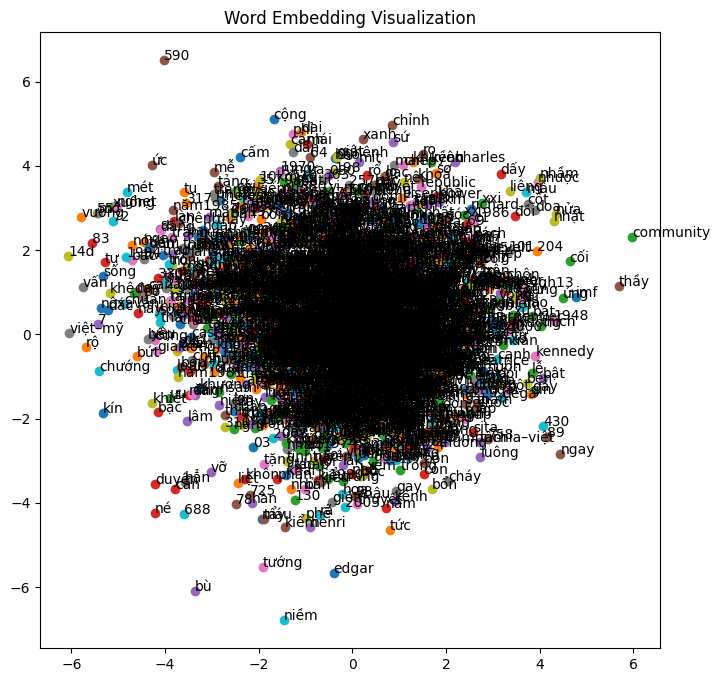

In [60]:
plt.figure(figsize=(8,8))

for word, idx in tokenizer.word_index.items():

    x,y = reduced[idx]

    plt.scatter(x,y)

    plt.text(x,y,word)

plt.title("Word Embedding Visualization")

plt.show()

In [61]:
from sklearn.metrics.pairwise import cosine_similarity

def most_similar(word):

    idx = word2idx[word]

    vec = embeddings[idx].reshape(1,-1)

    sims = cosine_similarity(vec, embeddings)[0]

    nearest = sims.argsort()[-10:-1][::-1]

    for i in nearest:
        print(idx2word[i], sims[i])

In [72]:
most_similar("Hiệp_định")

hiệp_định 0.56407404
thoả_thuận 0.5270924
Quyết_định 0.4116897
kỹ_nghệ 0.3893379
Cam_kết 0.38622615
Hiệp_định_sơ_bộ 0.3778414
17-11-1946 0.37580734
đồng_thời 0.37144172
hiệp_ước 0.36028287


In [65]:
print(list(tokenizer.word_index.items())[:2000])

[('và', 1), ('năm', 2), ('nam', 3), ('của', 4), ('chiến', 5), ('việt', 6), ('quân', 7), ('được', 8), ('chính', 9), ('trong', 10), ('các', 11), ('không', 12), ('tại', 13), ('bộ', 14), ('pháp', 15), ('dân', 16), ('đã', 17), ('bắc', 18), ('quốc', 19), ('là', 20), ('công', 21), ('ngày', 22), ('miền', 23), ('cho', 24), ('vào', 25), ('thành', 26), ('trung', 27), ('sự', 28), ('định', 29), ('có', 30), ('để', 31), ('tháng', 32), ('từ', 33), ('với', 34), ('hội', 35), ('động', 36), ('lượng', 37), ('đầu', 38), ('lực', 39), ('chủ', 40), ('nước', 41), ('số', 42), ('một', 43), ('đại', 44), ('phủ', 45), ('đoàn', 46), ('tế', 47), ('đến', 48), ('việc', 49), ('hành', 50), ('sản', 51), ('nhân', 52), ('sau', 53), ('ra', 54), ('quan', 55), ('chỉ', 56), ('lập', 57), ('tỉnh', 58), ('nhiều', 59), ('000', 60), ('người', 61), ('đội', 62), ('toàn', 63), ('1', 64), ('trị', 65), ('ở', 66), ('khu', 67), ('biên', 68), ('đảng', 69), ('liên', 70), ('tăng', 71), ('cách', 72), ('bị', 73), ('đồng', 74), ('vụ', 75), ('tổng